# Replicating Eppink et al. (2016): a narrated walkthrough

**Team 3 · ECON S5560 · Week 5 checkpoint**

This notebook walks through *how* we reproduced the paper's main result, including the dead ends. The five numbered scripts in this folder are the clean version of the same steps (`python run_all.py`). This notebook is the lab notebook.

> Eppink, F. V., Winden, M., Wright, W. C. C., & Greenhalgh, S. (2016). Non-market values in a cost-benefit world: Evidence from a choice experiment. *PLoS ONE, 11*(10), e0165365.

**The question in one line:** if councillors see dollar figures for some effects of a development (revenue, water-quality losses) but not others (cultural heritage), do their choices tilt toward the priced effects?

In [1]:
import numpy as np, pandas as pd, json, warnings
from IPython.display import display, Image, Markdown
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
from common import RAW_DTA, VARS, LABELS, PAPER_T3, fit_clogit, MixedLogit
from statsmodels.discrete.conditional_models import ConditionalLogit
import statsmodels.api as sm

## Step 1: What is in the raw file?
The only data the authors published is `S1Table.DTA` (Stata). We read it with pandas and keep the numeric codes so nothing is silently relabelled.

In [2]:
raw = pd.read_stata(RAW_DTA, convert_categoricals=False)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns, {raw.id.nunique()} respondents")
print("rows per respondent:", raw.groupby("id").size().value_counts().to_dict())
print("chosen options per respondent x card:", raw.groupby(["id", "choice_set"]).alternative_choice.sum().value_counts().to_dict())

2,160 rows x 147 columns, 180 respondents
rows per respondent: {12: 180}
chosen options per respondent x card: {1.0: 720}


Every respondent has **12 rows = 4 cards × 3 options** (Option A, Option B, status quo), with exactly one option chosen per card. The file is already in the "long" format a conditional logit needs. Here is one respondent:

In [3]:
raw.loc[raw.id == 2, ["id", "treatment", "choice_set", "choice_variables", "alternatives", "development",
                      "waterquality", "cult_impact", "alternative_choice"]]

,id,treatment,choice_set,choice_variables,alternatives,development,waterquality,cult_impact,alternative_choice
12,2.0,3.0,1.0,6.0,1.0,3.0,3.0,1.0,0.0
13,2.0,3.0,1.0,6.0,2.0,2.0,1.0,3.0,1.0
14,2.0,3.0,1.0,6.0,3.0,1.0,1.0,1.0,0.0
15,2.0,3.0,2.0,7.0,1.0,4.0,1.0,3.0,1.0
16,2.0,3.0,2.0,7.0,2.0,3.0,2.0,3.0,0.0
17,2.0,3.0,2.0,7.0,3.0,1.0,1.0,1.0,0.0
18,2.0,3.0,3.0,8.0,1.0,2.0,2.0,2.0,0.0
19,2.0,3.0,3.0,8.0,2.0,4.0,1.0,2.0,1.0
20,2.0,3.0,3.0,8.0,3.0,1.0,1.0,1.0,0.0
21,2.0,3.0,4.0,12.0,1.0,2.0,2.0,2.0,1.0


`choice_variables` is the **design card** (1–12) and `alternatives` is the option (3 = status quo). Codes: development 1 = none, 2 = limited, 3 = residential, 4 = commercial; water 1 = high, 2 = medium, 3 = low; cultural 1 = none, 2 = Stables, 3 = Stables & landscape.

## Step 2: Which respondents did the authors use?
Table 3 reports **N = 1,968** (all) and **N = 1,476** (councillors). With 12 rows per person, that is **164** and **123** people, but the file has 180. We first tried the obvious filters:

In [4]:
p = raw.groupby("id").first()
sq_count = raw[raw.alternatives == 3].groupby("id").alternative_choice.sum()
cands = {
    "everyone": p.finished > -1,
    "finished == 1": p.finished == 1,
    "role answered": p.role.notna(),
    "finished & role answered": (p.finished == 1) & p.role.notna(),
    "not an always-status-quo respondent": p.statusquo == 0,
    "involved in planning": p.involved_planning == 1,
}
pd.DataFrame({"respondents": {k: int(m.sum()) for k, m in cands.items()},
              "councillors (role==1)": {k: int((m & (p.role == 1)).sum()) for k, m in cands.items()}})

,respondents,councillors (role==1)
everyone,180,132
finished == 1,171,126
role answered,167,132
finished & role answered,161,126
not an always-status-quo respondent,167,121
involved in planning,169,132


None of these gives 164. The answer is in the raw survey-answer columns `T{treatment}_{card}a`, which record the option each person picked on each card they answered:

In [5]:
ans_cols = [f"T{t}_{k}a" for t in (1, 2, 3) for k in range(1, 13)]
n_answered = p[ans_cols].notna().sum(axis=1)
print("cards actually answered:", n_answered.value_counts().sort_index().to_dict())
inc = n_answered[n_answered < 4].index
print("\nDesign cards stored for the 16 incomplete respondents (4 'answers' each):")
print(raw[raw.id.isin(inc)].groupby("id").choice_variables.apply(lambda s: sorted(s.astype(int).unique())).to_string())

cards actually answered: {1: 5, 2: 2, 3: 9, 4: 164}

Design cards stored for the 16 incomplete respondents (4 'answers' each):
id
22.0     [1, 7, 11]
32.0         [4, 5]
60.0     [2, 9, 11]
89.0      [1, 2, 8]
111.0     [1, 3, 7]
123.0    [1, 7, 12]
158.0     [1, 2, 6]
179.0           [9]
186.0        [3, 8]
193.0     [5, 8, 9]
194.0           [7]
199.0     [6, 7, 9]
200.0    [4, 8, 12]
207.0          [11]
213.0           [7]
214.0           [3]


**164 people answered all four cards.** The other 16 answered one to three, but the long file still gives them four "chosen" cards, because their blanks were filled with **copies of cards they did answer** (respondent 179 has card 9 four times). Dropping them gives exactly N = 1,968. ✔

For councillors, the role code gives 121, two short of 123 (and of the paper's "75% councillors": 123/164 = 75.0%). The free-text "Other" answers settle it:

In [6]:
comp = p[n_answered == 4]
print("role == 1 among complete respondents:", int((comp.role == 1).sum()))
print(comp.loc[comp.role_text.str.strip() != "", ["role", "role_text"]].to_string())

role == 1 among complete respondents: 121
       role                                                  role_text
id                                                                    
2.0     6.0                                                   Projects
19.0    6.0                                   Both policy and consents
34.0    6.0              Farmer on both sides of Shannon Town Boundary
39.0    6.0  Councillor but also Resource Consent Hearing Commissioner
81.0    6.0                                                 Consultant
90.0    6.0                                                   director
168.0   6.0                                                      Mayor


A **Mayor** and a **"Councillor but also Resource Consent Hearing Commissioner"** are elected members. Adding them gives **123 → N = 1,476**. ✔ (`01_parse_data.py` does all of this with assertions and writes `output/data/choice_long.csv`.)

## Step 3: Table 1 (who answered)

In [7]:
t1 = pd.read_csv("output/tables/table1_comparison.csv"); t1

,variable,category,paper,ours_all_180,ours_complete_164,diff_all
0,Gender,Female,32.5,32.5,31.9,0.0
1,Gender,Male,67.5,67.5,68.1,-0.0
2,Age,<40,8.4,8.4,8.0,-0.0
3,Age,40–49,14.8,14.8,14.7,0.0
4,Age,50–59,27.7,27.7,28.7,0.0
5,Age,60–69,36.8,36.8,36.7,-0.0
6,Age,>70,12.3,12.3,12.0,-0.0
7,Personal residence,Rural,41.8,41.8,41.5,-0.0
8,Personal residence,Urban,58.2,58.2,58.5,0.0
9,City inhabitants,">50,000",36.7,39.1,40.4,2.4


Gender, age and residence match **exactly on all 180 respondents**, so Table 1 describes everyone who started, not the 164 in the models. The town-size row does not match under any sample we tried; we flag it rather than force it.

## Step 4: Building the regression variables
The main effects are dummies relative to the status quo (no development, high water, no cultural impact). The paper's treatment effects are *attribute level × "a dollar figure was shown for that attribute"*: development $ in T2 and T3, water $ only in T3.

One trap: the file ships ready-made interactions, but `water_high{t}` is **high** water × treatment, not low:

In [8]:
pd.crosstab([raw.waterquality.map({1: "High", 2: "Medium", 3: "Low"}), raw.treatment], raw.water_high3)

water_high3             0.0  1.0
waterquality treatment          
High         1.0        413    0
             2.0        421    0
             3.0          0  374
Low          1.0        146    0
             2.0        138    0
             3.0        133    0
Medium       1.0        185    0
             2.0        185    0
             3.0        165    0

In [9]:
df = pd.read_csv("output/data/choice_long.csv", keep_default_na=False, na_values=[""]); df = df[df.complete == 1]
df[["id", "treatment", "card", "alt_label", "development", "water", "chosen"] + VARS].head(6)

,id,treatment,card,alt_label,development,water,chosen,dev_limited,dev_high,dev_com,wat_med,wat_low,cult_s,cult_sl,lim_money,res_money,com_money,med_money,low_money
0,1,1,1,Option A,Residential,High,1,0,1,0,0,0,0,1,0,0,0,0,0
1,1,1,1,Option B,Limited,Low,0,1,0,0,0,1,0,0,0,0,0,0,0
2,1,1,1,Status quo,None,High,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,1,3,Option A,Residential,Low,0,0,1,0,0,1,0,1,0,0,0,0,0
4,1,1,3,Option B,Limited,Medium,1,1,0,0,1,0,1,0,0,0,0,0,0
5,1,1,3,Status quo,None,High,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step 5: Finding the paper's model 1 specification
A first textbook conditional logit (one group per person per card) did **not** reproduce Table 3. The coefficients were about half the published size. The published log likelihood is the clue: a correct model of 3-option choices can never fit worse than giving every option probability 1/3, which scores 656 × ln(1/3) = **−720.7**. The paper reports **−852.9**, so the published model must group the data differently. We tried the plausible groupings:

In [10]:
paper = PAPER_T3["m1"]
def try_group(g):
    r = fit_clogit(df, g)            # same estimator as 03_conditional_logit.py
    return r["ll"], r["coef"]
specs = {"one person x one card (textbook)": "occasion", "one person (all 4 cards)": "id",
         "card position 1-4": "choice_set", "design card 1-12 (pooled across people)": "card"}
rows = []
for name, g in specs.items():
    ll, b = try_group(g)
    rows.append({"grouping": name, "log L": round(ll, 2), **{LABELS[v]: round(x, 3) for v, x in zip(VARS[:3] + VARS[-2:], list(b[:3]) + list(b[-2:]))}})
bl = sm.Logit(df.chosen, sm.add_constant(df[VARS])).fit(disp=0)
rows.append({"grouping": "binary logit, no grouping", "log L": round(bl.llf, 2), **{LABELS[v]: round(x, 3) for v, x in zip(VARS[:3] + VARS[-2:], list(bl.params.values[1:4]) + list(bl.params.values[-2:]))}})
rows.append({"grouping": "PUBLISHED (paper)", "log L": paper["ll"], **{LABELS[v]: x for v, x in zip(VARS[:3] + VARS[-2:], paper["coef"][:3] + paper["coef"][-2:])}})
pd.DataFrame(rows).set_index("grouping")

,log L,Development: Limited,Development: Residential,Development: Commercial,Medium water × $ shown,Low water × $ shown
grouping,,,,,,
one person x one card (textbook),-485.18,2.235,2.337,2.174,-0.584,-1.023
one person (all 4 cards),-733.23,1.824,1.740,1.722,-0.706,-1.161
card position 1-4,-938.23,2.143,1.965,1.910,-0.436,-0.944
design card 1-12 (pooled across people),-852.92,4.260,4.553,4.112,-0.473,-0.919
"binary logit, no grouping",-954.14,2.059,1.884,1.840,-0.434,-0.938
PUBLISHED (paper),-852.90,4.260,4.553,4.112,-0.473,-0.919


Grouping by **design card**, which pools everyone who answered card *k* into one giant "choice situation", reproduces the published log likelihood (−852.92 vs −852.9) and every coefficient. The final estimates, with p-values, for both samples:

In [11]:
cl = pd.read_csv("output/tables/table3_cl.csv")
cl[["model", "variable", "paper_coef", "paper_p", "rep_coef", "rep_p", "match", "corr_coef", "corr_p_cluster"]]

,model,variable,paper_coef,paper_p,rep_coef,rep_p,match,corr_coef,corr_p_cluster
0,(1) CL · All,Development: Limited,4.260,0.000,4.260,0.000,yes,2.235,0.001
1,(1) CL · All,Development: Residential,4.553,0.000,4.553,0.000,yes,2.337,0.000
2,(1) CL · All,Development: Commercial,4.112,0.000,4.112,0.000,yes,2.174,0.000
3,(1) CL · All,Water quality: Medium,-3.954,0.000,-3.954,0.000,yes,-2.227,0.000
4,(1) CL · All,Water quality: Low,-6.135,0.000,-6.135,0.000,yes,-3.818,0.000
5,(1) CL · All,Cultural: Stables,-0.822,0.080,-0.822,0.080,yes,-0.406,0.336
6,(1) CL · All,Cultural: Stables & landscape,-1.672,0.031,-1.673,0.001,coef,-0.999,0.015
7,(1) CL · All,Limited × $ shown,0.205,0.452,0.205,0.452,yes,0.397,0.273
8,(1) CL · All,Residential × $ shown,0.670,0.018,0.699,0.018,NO,0.836,0.039
9,(1) CL · All,Commercial × $ shown,0.308,0.282,0.308,0.282,yes,0.512,0.191


In [12]:
print(cl.match.value_counts().to_string())
display(Markdown("**20 of 24** coefficient and p-value pairs match to 3 decimals. The other 4 are reporting errors in the paper (see `08_debug_discrepancies.py`): "
                 "model 2's water \"coefficients\" −0.393 and −0.602 are exactly its standard errors (the coefficients are −3.891 and −6.184); model 1's Residential × \$ is "
                 "printed 0.670 (data: 0.699, same p-value); model 1's Stables & landscape p-value is printed 0.031 (data: 0.001). "
                 "`crosscheck_clogit.R` gets identical numbers with R's `survival::clogit`."))

match
yes     20
NO       3
coef     1


**20 of 24** coefficient and p-value pairs match to 3 decimals. The other 4 are reporting errors in the paper (see `08_debug_discrepancies.py`): model 2's water "coefficients" −0.393 and −0.602 are exactly its standard errors (the coefficients are −3.891 and −6.184); model 1's Residential × \$ is printed 0.670 (data: 0.699, same p-value); model 1's Stables & landscape p-value is printed 0.031 (data: 0.001). `crosscheck_clogit.R` gets identical numbers with R's `survival::clogit`.

**Corrected specification.** `corr_coef` and `corr_p_cluster` re-estimate the same model grouped the textbook way (one person × one card), with standard errors clustered by respondent. Coefficients shrink, but **every sign survives**, and the $-shown effects for residential development and medium/low water stay significant or borderline.

## Step 6: Mixed logit (models 3–4)
The mixed logit gives each respondent their own coefficients and has to be fitted by simulation. Stata's `mixlogit` nests the card grouping *inside* each respondent, so here the grouping problem disappears. We coded the estimator ourselves (`common.MixedLogit`, following Train 2009). One fit with the paper's 500 draws:

In [13]:
start = np.r_[fit_clogit(df, "occasion")["coef"], 0.1 * np.ones(len(VARS))]
m = MixedLogit(df, n_draws=500, seed=0).fit(start)
print(f"log likelihood {m.ll:.2f} (paper {PAPER_T3['m3']['ll']}), converged: {m.converged}")
pd.DataFrame({"paper": PAPER_T3["m3"]["coef"], "ours (500 draws, seed 0)": m.theta[:12].round(3)}, index=[LABELS[v] for v in VARS])

log likelihood -425.90 (paper -421.92), converged: True


,paper,"ours (500 draws, seed 0)"
Development: Limited,6.819,5.748
Development: Residential,6.259,5.692
Development: Commercial,6.387,6.209
Water quality: Medium,-7.324,-6.974
Water quality: Low,-14.950,-14.635
Cultural: Stables,-1.239,-1.058
Cultural: Stables & landscape,-2.765,-1.968
Limited × $ shown,1.290,2.163
Residential × $ shown,3.222,2.515
Commercial × $ shown,1.754,1.217


The fit statistic is right, but the coefficients depend on *which* random draws are used. `04_mixed_logit.py` refits with 20 different draw sequences plus one 2,000-draw run:

,model,variable,paper_coef,primary_coef,primary_p,sens_min,sens_median,sens_max,paper_inside_range
0,(3) ML · All,Development: Limited,6.819,7.197,0.002,5.748,8.629,18.228,True
1,(3) ML · All,Development: Residential,6.259,6.778,0.003,5.176,7.531,14.761,True
2,(3) ML · All,Development: Commercial,6.387,6.581,0.001,5.194,7.663,14.515,True
3,(3) ML · All,Water quality: Medium,-7.324,-7.554,0.000,-15.829,-9.029,-6.372,True
4,(3) ML · All,Water quality: Low,-14.950,-14.589,0.001,-37.837,-18.142,-12.497,True
5,(3) ML · All,Cultural: Stables,-1.239,-1.747,0.186,-6.661,-1.966,-0.168,True
6,(3) ML · All,Cultural: Stables & landscape,-2.765,-2.954,0.046,-9.103,-3.368,-1.924,True
7,(3) ML · All,Limited × $ shown,1.290,1.740,0.126,1.231,1.960,5.032,True
8,(3) ML · All,Residential × $ shown,3.222,2.976,0.039,2.515,3.896,7.725,True
9,(3) ML · All,Commercial × $ shown,1.754,1.521,0.142,1.217,1.924,4.059,True


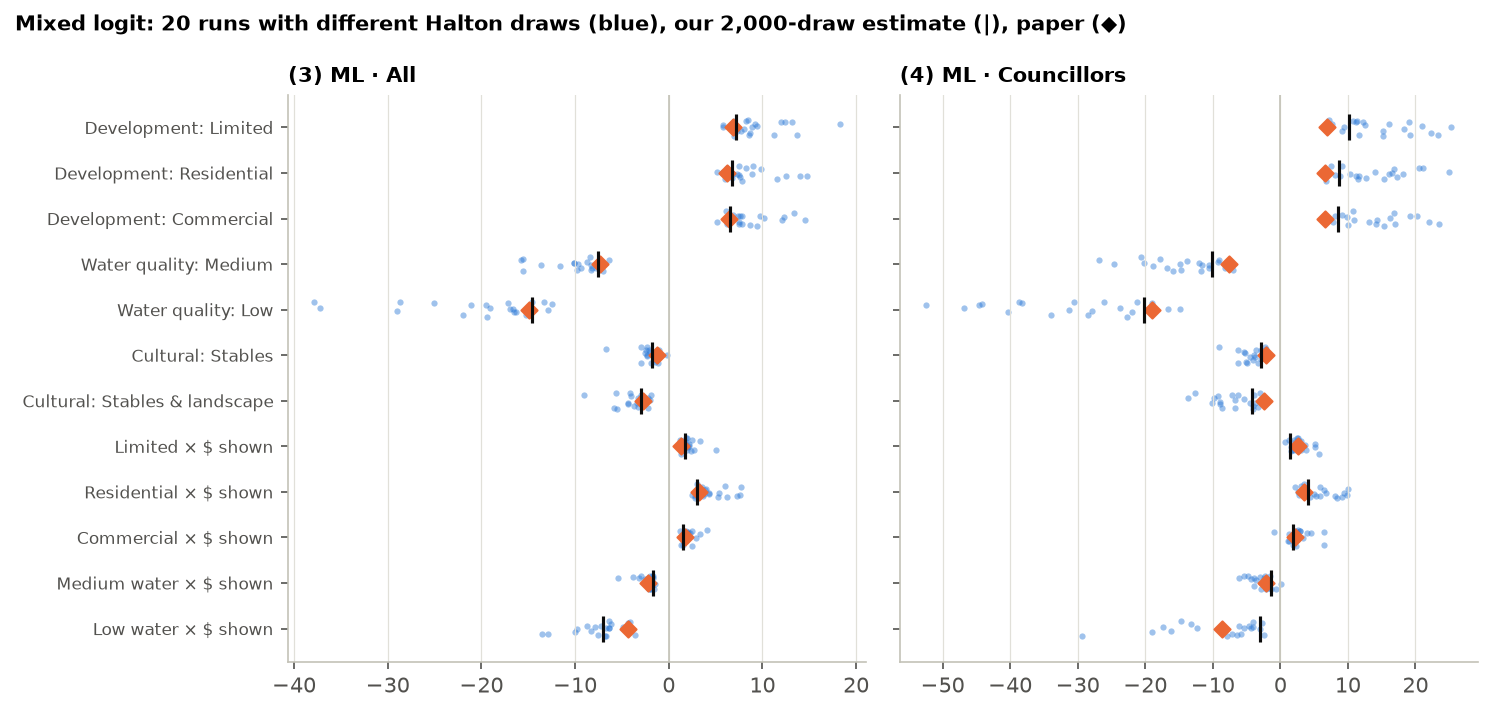

In [14]:
ml = pd.read_csv("output/tables/table3_ml.csv")
display(ml[["model", "variable", "paper_coef", "primary_coef", "primary_p", "sens_min", "sens_median", "sens_max", "paper_inside_range"]])
Image("output/figures/ml_sensitivity.png")

The published model 3 values sit comfortably inside our spread. Model 4 (123 councillors) is much less stable. Its headline "low water × $" effect (−8.65, p = 0.015 in the paper) comes out at about −3 and insignificant with 2,000 draws. **The mixed logit supports the direction of the finding, not its precise size.**

Figure 2 (each councillor's own treatment-effect coefficient), rebuilt from our model 4:

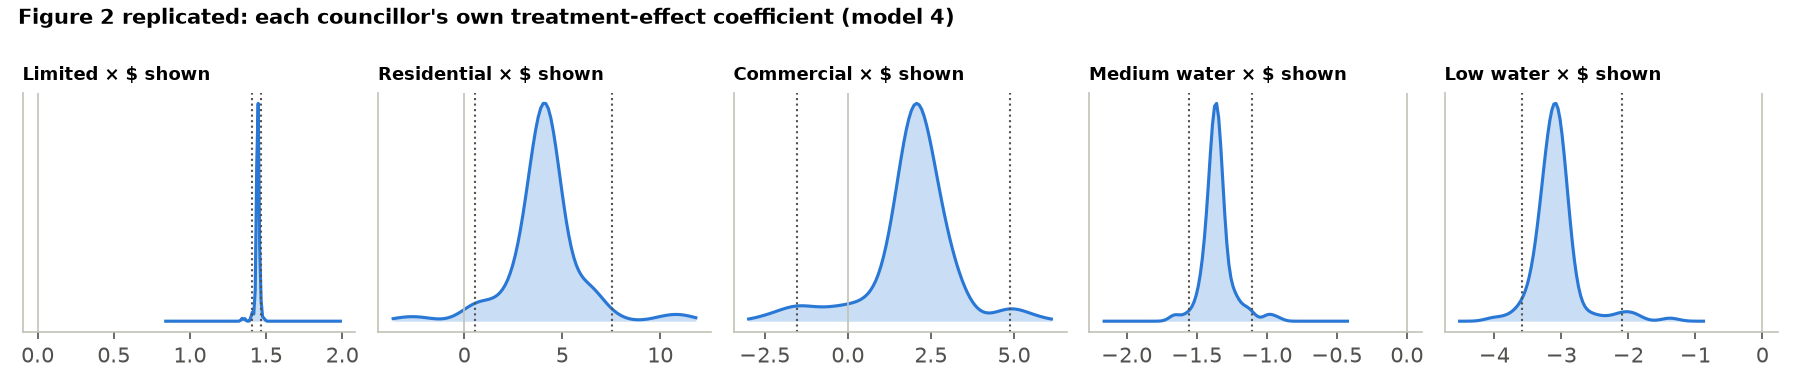

In [15]:
Image("output/figures/fig2_individual_effects.png")

## Where this leaves us (Week 5)
| Target | Status |
|---|---|
| Sample (N = 1,968 / 1,476) | ✔ exact, and we know which 16 people were dropped and why |
| Table 1 | ✔ 9 of 13 cells exact; town size does not match |
| Table 3, models 1–2 (CL) | ✔ 20/24 exact; the other 4 traced to reporting errors; confirmed in R |
| Table 3, models 3–4 (ML) | ≈ same signs and magnitudes within simulation noise; model 4 fragile |
| Figure 1, Figure 2 | ✔ rebuilt |

**For the appraisal:** (1) the CL pools each card across respondents; (2) the ML results are sensitive to simulation draws; (3) there are reporting errors (standard errors printed as coefficients) and method descriptions that don't match the data ("15 individuals dropped" is most likely Stata's `burn(15)`); (4) development dummies double as a "new plan vs status quo" constant; (5) the dollar effects are identified from about 55 people per group.